# Taller K-means en 3D (k = 2)

## Objetivo

- Comprender y ejecutar el algoritmo **k-means** paso a paso.
- Calcular **distancias euclidianas** en 3 dimensiones.
- **Recalcular centroides** en un espacio de 3 características.
- Implementar k-means en Python con **scikit-learn** y **comparar** resultados.

## Conjunto de datos

6 clientes descritos por 3 características (X1, X2, X3).

In [1]:
import numpy as np
import pandas as pd

clientes = ['C1', 'C2', 'C3', 'C4', 'C5', 'C6']
X = np.array([
    [40, 20, 25],   # C1
    [42, 22, 27],   # C2
    [25, 80, 45],   # C3
    [23, 77, 43],   # C4
    [60, 15, 30],   # C5
    [62, 18, 33],   # C6
], dtype=float)

pd.DataFrame(X, index=clientes, columns=['X1', 'X2', 'X3'])

,X1,X2,X3
C1,40.0,20.0,25.0
C2,42.0,22.0,27.0
C3,25.0,80.0,45.0
C4,23.0,77.0,43.0
C5,60.0,15.0,30.0
C6,62.0,18.0,33.0


## Inicialización de centroides

Con **k = 2 clusters**, los centroides iniciales son:

- **Centroide 1 (C1):** (40, 20, 25)
- **Centroide 2 (C2):** Cliente C3 → (25, 80, 45)

In [2]:
centroide_1 = np.array([40, 20, 25], dtype=float)   # Cliente C1
centroide_2 = np.array([25, 80, 45], dtype=float)   # Cliente C3

print('Centroide 1:', centroide_1)
print('Centroide 2:', centroide_2)

Centroide 1: [40. 20. 25.]
Centroide 2: [25. 80. 45.]


## Distancia euclidiana en 3D

$$d(P, Q) = \sqrt{(x_2 - x_1)^2 + (y_2 - y_1)^2 + (z_2 - z_1)^2}$$

In [3]:
def distancia_euclidiana(p, q):
    """Distancia euclidiana entre dos puntos en 3D."""
    return np.sqrt(np.sum((p - q) ** 2))

## Iteración 1

### Tabla de distancias
Distancia de cada cliente a los centroides iniciales y cluster asignado (el más cercano).

In [4]:
filas = []
for i, nombre in enumerate(clientes):
    d1 = distancia_euclidiana(X[i], centroide_1)
    d2 = distancia_euclidiana(X[i], centroide_2)
    cluster = 1 if d1 <= d2 else 2
    filas.append([nombre, round(d1, 4), round(d2, 4), cluster])

tabla_iter1 = pd.DataFrame(filas, columns=['Cliente', 'Dist a C1', 'Dist a C2', 'Cluster asignado'])
tabla_iter1

,Cliente,Dist a C1,Dist a C2,Cluster asignado
0,C1,0.0000,65.0000,1
1,C2,3.4641,63.0635,1
2,C3,65.0000,0.0000,2
3,C4,62.1450,4.1231,2
4,C5,21.2132,75.3326,1
5,C6,23.4947,73.1915,1


### Recálculo de centroides
Cada centroide nuevo es el promedio de los puntos de su cluster.

In [5]:
asignacion_1 = tabla_iter1['Cluster asignado'].values
centroide_1 = X[asignacion_1 == 1].mean(axis=0)
centroide_2 = X[asignacion_1 == 2].mean(axis=0)

print('Cluster 1:', [clientes[i] for i in range(6) if asignacion_1[i] == 1])
print('Nuevo Centroide 1:', centroide_1)
print('Cluster 2:', [clientes[i] for i in range(6) if asignacion_1[i] == 2])
print('Nuevo Centroide 2:', centroide_2)

Cluster 1: ['C1', 'C2', 'C5', 'C6']
Nuevo Centroide 1: [51.   18.75 28.75]
Cluster 2: ['C3', 'C4']
Nuevo Centroide 2: [24.  78.5 44. ]


## Iteración 2

### Tabla de distancias
Se repite el cálculo usando los centroides recalculados.

In [6]:
filas = []
for i, nombre in enumerate(clientes):
    d1 = distancia_euclidiana(X[i], centroide_1)
    d2 = distancia_euclidiana(X[i], centroide_2)
    cluster = 1 if d1 <= d2 else 2
    filas.append([nombre, round(d1, 4), round(d2, 4), cluster])

tabla_iter2 = pd.DataFrame(filas, columns=['Cliente', 'Dist a C1', 'Dist a C2', 'Cluster asignado'])
tabla_iter2

,Cliente,Dist a C1,Dist a C2,Cluster asignado
0,C1,11.6887,63.5551,1
1,C2,9.7275,61.6867,1
2,C3,68.4954,2.0616,2
3,C4,66.1825,2.0616,2
4,C5,9.8298,74.3253,1
5,C6,11.8163,72.2859,1


### Recálculo de centroides y verificación de convergencia

In [7]:
asignacion_2 = tabla_iter2['Cluster asignado'].values
centroide_1 = X[asignacion_2 == 1].mean(axis=0)
centroide_2 = X[asignacion_2 == 2].mean(axis=0)

print('Nuevo Centroide 1:', centroide_1)
print('Nuevo Centroide 2:', centroide_2)

convergio = (asignacion_1 == asignacion_2).all()
print('Las asignaciones no cambiaron (convergencia):', convergio)

Nuevo Centroide 1: [51.   18.75 28.75]
Nuevo Centroide 2: [24.  78.5 44. ]
Las asignaciones no cambiaron (convergencia): True


## Clusters finales

In [8]:
centroides_finales = np.vstack([centroide_1, centroide_2])
for k in (1, 2):
    miembros = [clientes[i] for i in range(6) if asignacion_2[i] == k]
    print(f'Cluster {k}: {miembros}  ->  centroide {centroides_finales[k-1]}')

Cluster 1: ['C1', 'C2', 'C5', 'C6']  ->  centroide [51.   18.75 28.75]
Cluster 2: ['C3', 'C4']  ->  centroide [24.  78.5 44. ]


## Implementación en Python con scikit-learn

Misma inicialización para poder comparar con el cálculo paso a paso.

In [9]:
from sklearn.cluster import KMeans

init_sk = np.array([[40, 20, 25], [25, 80, 45]], dtype=float)
km = KMeans(n_clusters=2, init=init_sk, n_init=1, random_state=0)
labels_sk = km.fit_predict(X)

print('Etiquetas (0/1):', labels_sk)
print('Centroides finales:\n', km.cluster_centers_)
print('Inercia (SSE):', round(km.inertia_, 4))

Etiquetas (0/1): [0 0 1 1 0 0]
Centroides finales:
 [[51.   18.75 28.75]
 [24.   78.5  44.  ]]
Inercia (SSE): 476.0


## Comparación de resultados
scikit-learn usa etiquetas 0/1; las pasamos a 1/2 para comparar.

In [10]:
sk_1_2 = np.where(labels_sk == 0, 1, 2)
comparacion = pd.DataFrame({
    'Cliente': clientes,
    'Paso a paso': asignacion_2,
    'scikit-learn': sk_1_2,
})
print('Coinciden 100%:', (asignacion_2 == sk_1_2).all())
comparacion

Coinciden 100%: True


,Cliente,Paso a paso,scikit-learn
0,C1,1,1
1,C2,1,1
2,C3,2,2
3,C4,2,2
4,C5,1,1
5,C6,1,1


## Visualización 3D de los clusters
_(complementario)_ Muestra los 6 clientes coloreados por cluster y los centroides finales.

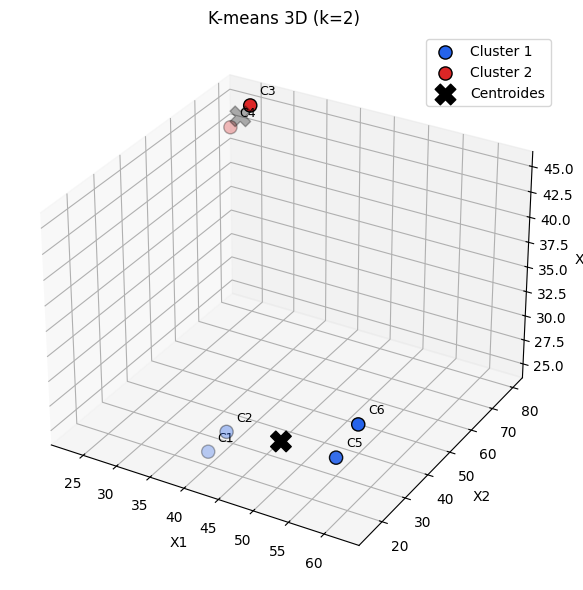

In [11]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
%matplotlib inline

col = {1: '#2563eb', 2: '#dc2626'}
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
for l in (1, 2):
    m = asignacion_2 == l
    ax.scatter(X[m, 0], X[m, 1], X[m, 2], c=col[l], s=90,
               edgecolors='k', label=f'Cluster {l}')
ax.scatter(centroides_finales[:, 0], centroides_finales[:, 1], centroides_finales[:, 2],
           c='black', marker='X', s=220, label='Centroides')
for i, c in enumerate(clientes):
    ax.text(X[i, 0] + 1, X[i, 1] + 1, X[i, 2] + 1, c, fontsize=9)
ax.set_xlabel('X1'); ax.set_ylabel('X2'); ax.set_zlabel('X3')
ax.set_title('K-means 3D (k=2)')
ax.legend()
plt.tight_layout()
plt.savefig('kmeans_3d.png', dpi=150)
plt.show()